<a href="https://www.kaggle.com/code/lalit7881/bmw-sales-intelligenc?scriptVersionId=299254905" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
# Set Global Aesthetics for professional rendering
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.facecolor'] = 'white'
sns.set_palette("viridis")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bmw-global-sales-and-market-data/bmw_global_sales_dataset.csv


In [2]:
df = pd.read_csv("/kaggle/input/bmw-global-sales-and-market-data/bmw_global_sales_dataset.csv")

In [3]:
df.head()

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   object 
 3   model                  1000 non-null   object 
 4   segment                1000 non-null   object 
 5   engine_type            1000 non-null   object 
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), object(4)
memory usage: 109.5+ K

In [5]:
df.describe()

,year,month,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000
mean,2019.448000,6.487000,76535.747000,279492.230000,200.230000,9.700000e-01,6.290000e+00,1.200000e+00,5.572000,633.192000
std,2.912005,3.510863,25360.933749,127010.559722,113.096127,1.977186e-14,3.199042e-14,2.265988e-14,2.944059,263.346628
min,2015.000000,1.000000,35060.000000,50363.000000,10.000000,9.700000e-01,6.290000e+00,1.200000e+00,1.000000,15.000000
25%,2017.000000,3.000000,54578.750000,173552.250000,101.750000,9.700000e-01,6.290000e+00,1.200000e+00,3.000000,432.750000
50%,2019.000000,7.000000,75726.000000,278733.500000,197.000000,9.700000e-01,6.290000e+00,1.200000e+00,6.000000,630.000000
75%,2022.000000,10.000000,98730.250000,390110.000000,297.000000,9.700000e-01,6.290000e+00,1.200000e+00,8.000000,842.500000
max,2024.000000,12.000000,119817.000000,498927.000000,399.000000,9.700000e-01,6.290000e+00,1.200000e+00,10.000000,1242.000000


In [6]:
df.isnull().sum()

year                     0
month                    0
country                  0
model                    0
segment                  0
engine_type              0
price_usd                0
marketing_spend_usd      0
dealership_count         0
fuel_price_usd           0
gdp_growth_percent       0
interest_rate_percent    0
competition_index        0
units_sold               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

year                       int64
month                      int64
country                   object
model                     object
segment                   object
engine_type               object
price_usd                  int64
marketing_spend_usd        int64
dealership_count           int64
fuel_price_usd           float64
gdp_growth_percent       float64
interest_rate_percent    float64
competition_index          int64
units_sold                 int64
dtype: object

In [9]:
df.shape

(1000, 14)

In [10]:
df.columns

Index(['year', 'month', 'country', 'model', 'segment', 'engine_type',
       'price_usd', 'marketing_spend_usd', 'dealership_count',
       'fuel_price_usd', 'gdp_growth_percent', 'interest_rate_percent',
       'competition_index', 'units_sold'],
      dtype='object')

In [11]:
df.nunique()

year                      10
month                     12
country                   10
model                     10
segment                    3
engine_type                4
price_usd                994
marketing_spend_usd      996
dealership_count         355
fuel_price_usd             1
gdp_growth_percent         1
interest_rate_percent      1
competition_index         10
units_sold               621
dtype: int64

## EDA

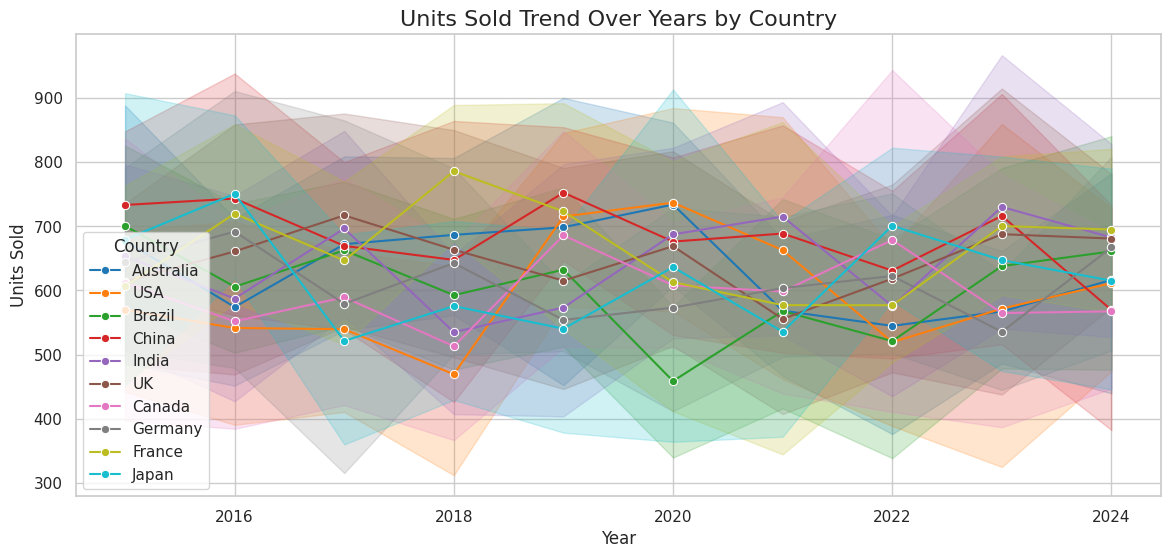

In [12]:
# Set Seaborn style
sns.set(style="whitegrid", palette="pastel", color_codes=True)
plt.rcParams['figure.figsize'] = (12, 6)

# -----------------------------
# 1. Units Sold Trend Over Years
# -----------------------------
plt.figure(figsize=(14,6))
sns.lineplot(data=df, x='year', y='units_sold', hue='country', marker='o', palette='tab10')
plt.title('Units Sold Trend Over Years by Country', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Units Sold')
plt.legend(title='Country')
plt.show()


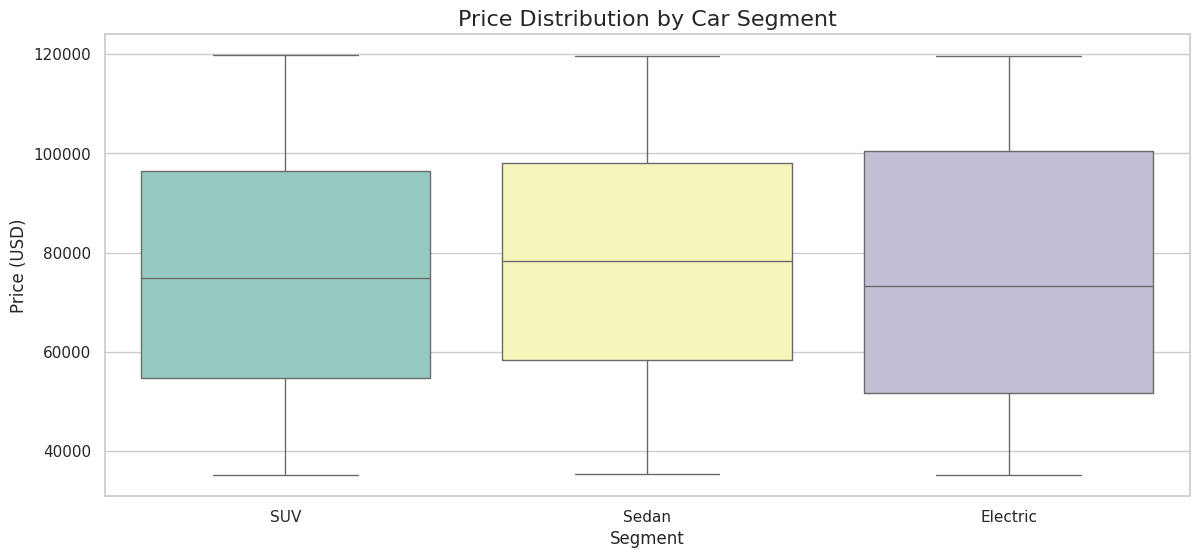

In [13]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='segment', y='price_usd', palette='Set3')
plt.title('Price Distribution by Car Segment', fontsize=16)
plt.xlabel('Segment')
plt.ylabel('Price (USD)')
plt.show()

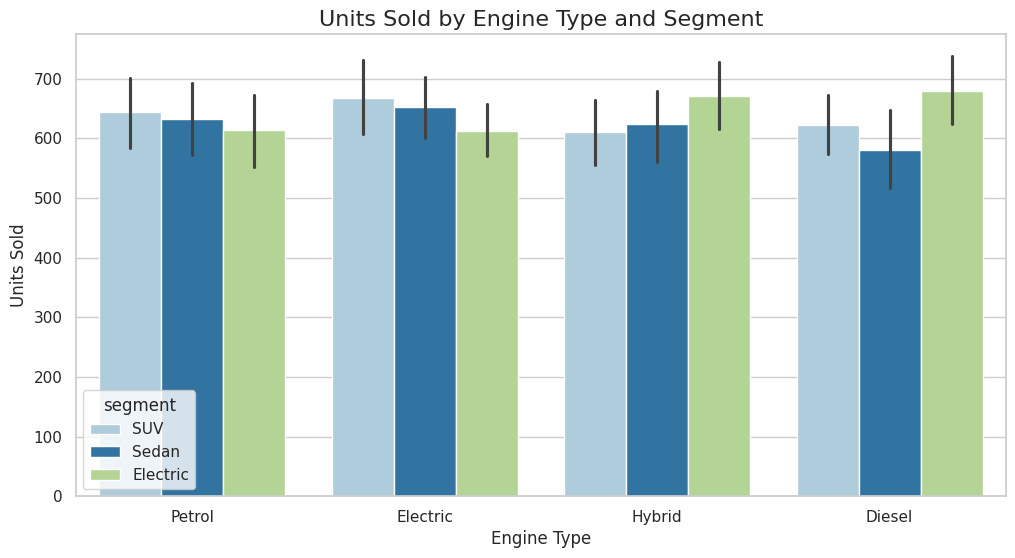

In [14]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='engine_type', y='units_sold', hue='segment', palette='Paired')
plt.title('Units Sold by Engine Type and Segment', fontsize=16)
plt.xlabel('Engine Type')
plt.ylabel('Units Sold')
plt.show()


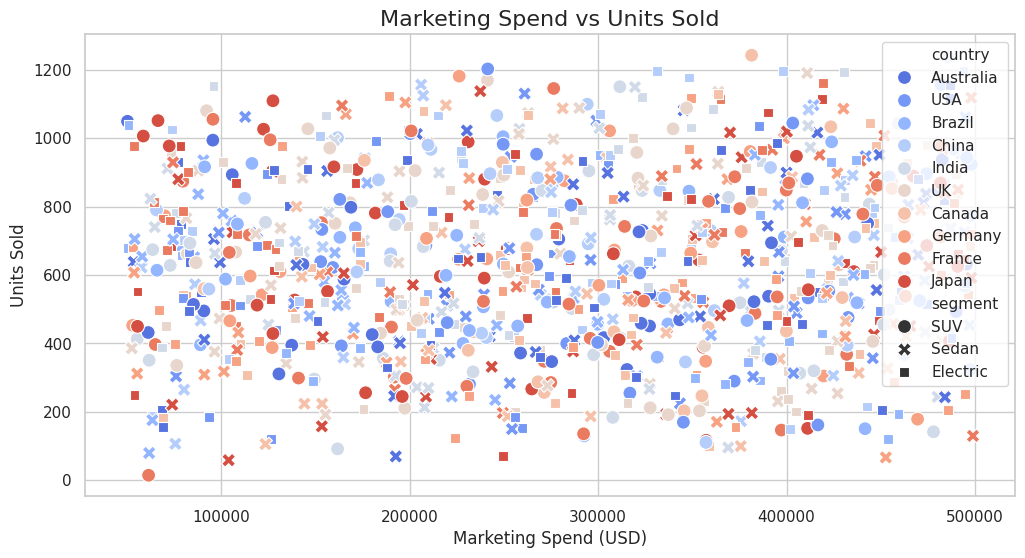

In [15]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='marketing_spend_usd', y='units_sold', hue='country', style='segment', palette='coolwarm', s=100)
plt.title('Marketing Spend vs Units Sold', fontsize=16)
plt.xlabel('Marketing Spend (USD)')
plt.ylabel('Units Sold')
plt.show()

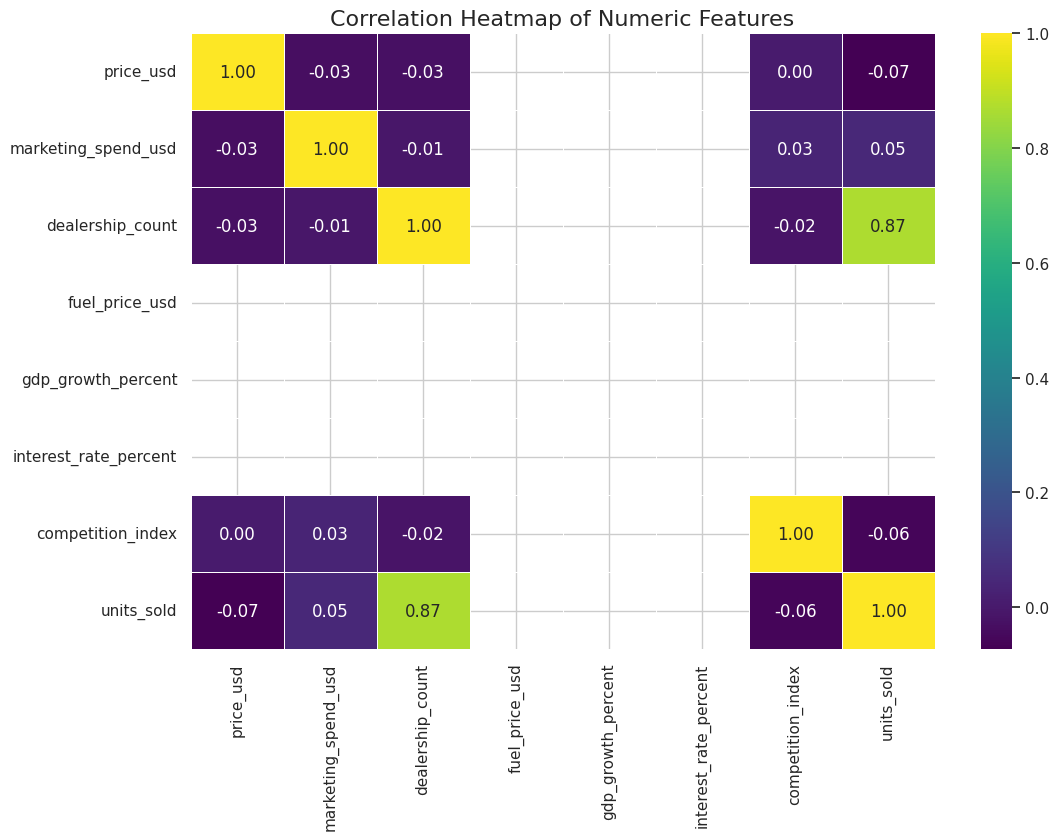

In [16]:
numeric_cols = ['price_usd', 'marketing_spend_usd', 'dealership_count', 'fuel_price_usd', 'gdp_growth_percent', 'interest_rate_percent', 'competition_index', 'units_sold']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='viridis', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.show()

In [17]:
fig = px.line(df, x='year', y='units_sold', color='model', line_dash='segment',
              title='Units Sold by Model Over Years', markers=True)
fig.show()

In [18]:
# Initializing Encoder
le = LabelEncoder()
df_ml = df.copy()

# Converting text columns to numerical codes
for col in ['country', 'model', 'segment', 'engine_type']:
    df_ml[f'{col}_encoded'] = le.fit_transform(df[col])

print("✅ Feature Engineering Complete: Data is now Machine-Readable.")

✅ Feature Engineering Complete: Data is now Machine-Readable.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb

In [20]:
df_ml = df.copy()  # your original dataframe

categorical_cols = ['country', 'model', 'segment', 'engine_type']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col + '_encoded'] = le.fit_transform(df_ml[col])
    label_encoders[col] = le

In [21]:
features = ['price_usd', 'marketing_spend_usd', 'dealership_count', 'gdp_growth_percent', 
            'country_encoded', 'model_encoded', 'segment_encoded', 'engine_type_encoded']
X = df_ml[features]
y = df_ml['units_sold']

# Optional: scale features (useful for Linear Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    "Linear Regression": LinearRegression()
}

results = {}
feature_importances = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    
    # Feature Importance (only tree-based models)
    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)


In [23]:
results_df = pd.DataFrame(results).T
print("Model Performance Comparison:\n")
print(results_df)

Model Performance Comparison:

                         RMSE         MAE        R2
Random Forest      135.100443  115.038775  0.732982
Gradient Boosting  138.653456  117.406311  0.718752
XGBoost            145.504000  124.725784  0.690274
Linear Regression  128.738421  110.160574  0.757538


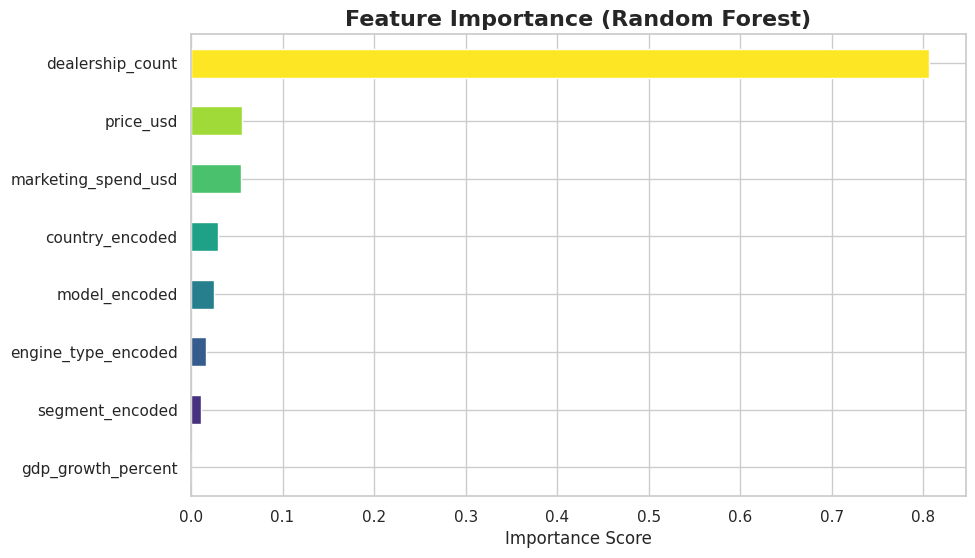

In [24]:
if "Random Forest" in feature_importances:
    plt.figure(figsize=(10,6))
    importances = feature_importances['Random Forest']
    importances.plot(kind='barh', color=plt.cm.viridis(np.linspace(0,1,len(importances))))
    plt.title('Feature Importance (Random Forest)', fontsize=16, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.show()

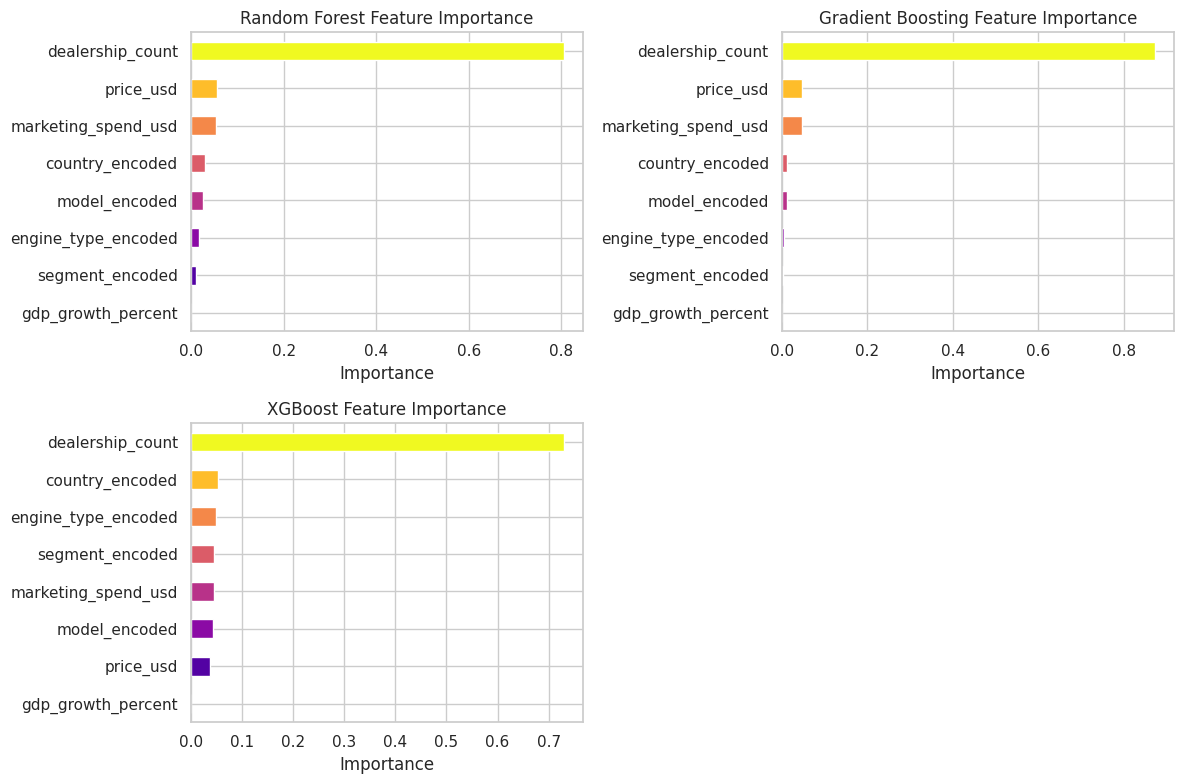

In [25]:
plt.figure(figsize=(12,8))
for i, (model_name, importance) in enumerate(feature_importances.items()):
    plt.subplot(2, 2, i+1)
    importance.plot(kind='barh', color=plt.cm.plasma(np.linspace(0,1,len(importance))))
    plt.title(f'{model_name} Feature Importance')
    plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

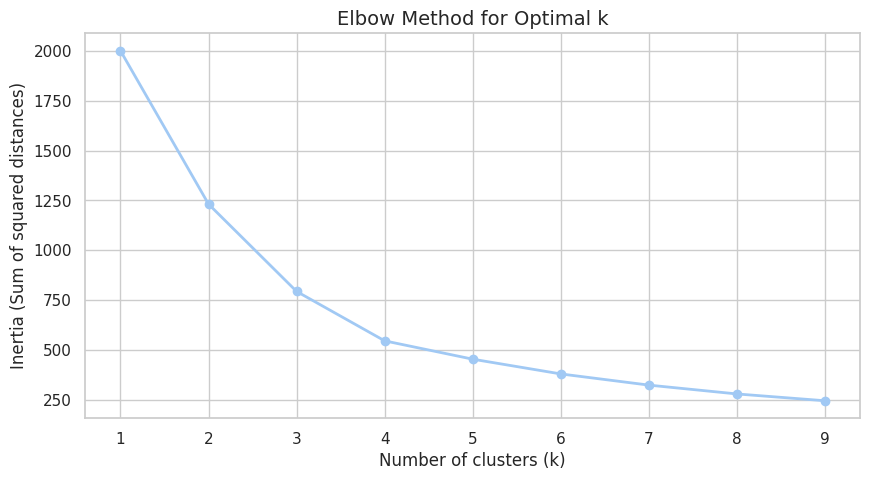

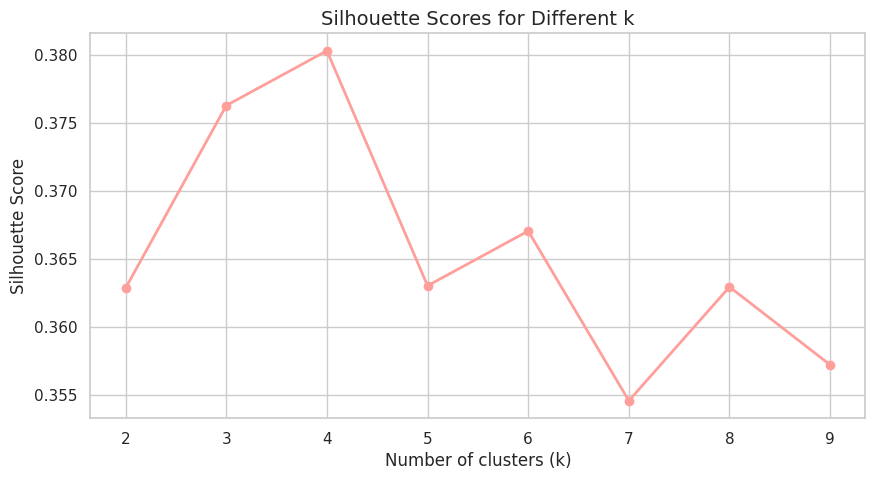

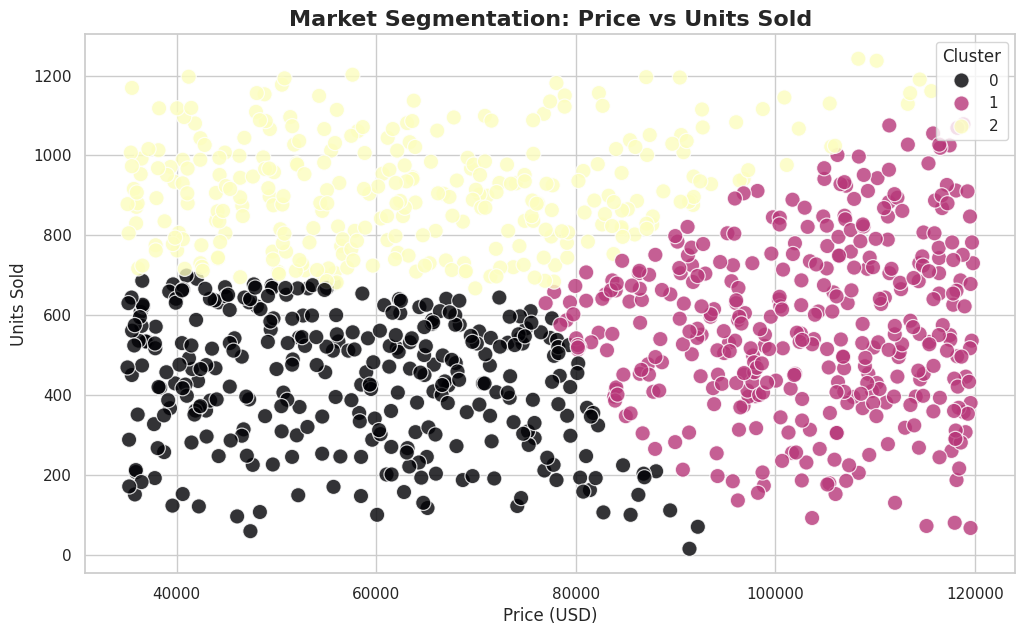

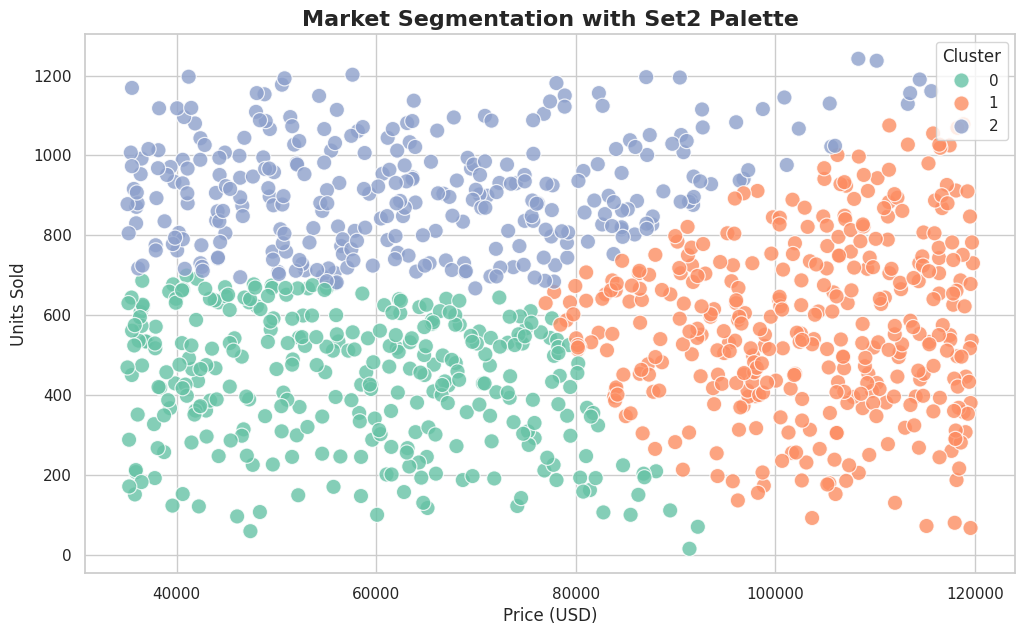

Cluster Centers:
        price_usd  units_sold  Cluster
0   57916.719243  433.006309        0
1  103036.614555  570.501348        1
2   63940.907051  911.131410        2


In [27]:
cluster_features = ['price_usd', 'units_sold']
X = df_ml[cluster_features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(K_range, inertia, 'bo-', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.show()

sil_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10,5))
plt.plot(range(2,10), sil_scores, 'ro-', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k', fontsize=14)
plt.show()

optimal_k = 3  # choose based on elbow/silhouette
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_ml['Market_Segment'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12,7))
sns.scatterplot(
    data=df_ml,
    x='price_usd',
    y='units_sold',
    hue='Market_Segment',
    palette='magma',   # gradient color
    s=120,
    alpha=0.8
)
plt.title('Market Segmentation: Price vs Units Sold', fontsize=16, fontweight='bold')
plt.xlabel('Price (USD)')
plt.ylabel('Units Sold')
plt.legend(title='Cluster')
plt.show()

# Optional: another color palette
plt.figure(figsize=(12,7))
sns.scatterplot(
    data=df_ml,
    x='price_usd',
    y='units_sold',
    hue='Market_Segment',
    palette='Set2',  # categorical color palette
    s=120,
    alpha=0.8
)
plt.title('Market Segmentation with Set2 Palette', fontsize=16, fontweight='bold')
plt.xlabel('Price (USD)')
plt.ylabel('Units Sold')
plt.legend(title='Cluster')
plt.show()


cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=cluster_features)
cluster_centers['Cluster'] = range(optimal_k)
print("Cluster Centers:\n", cluster_centers)

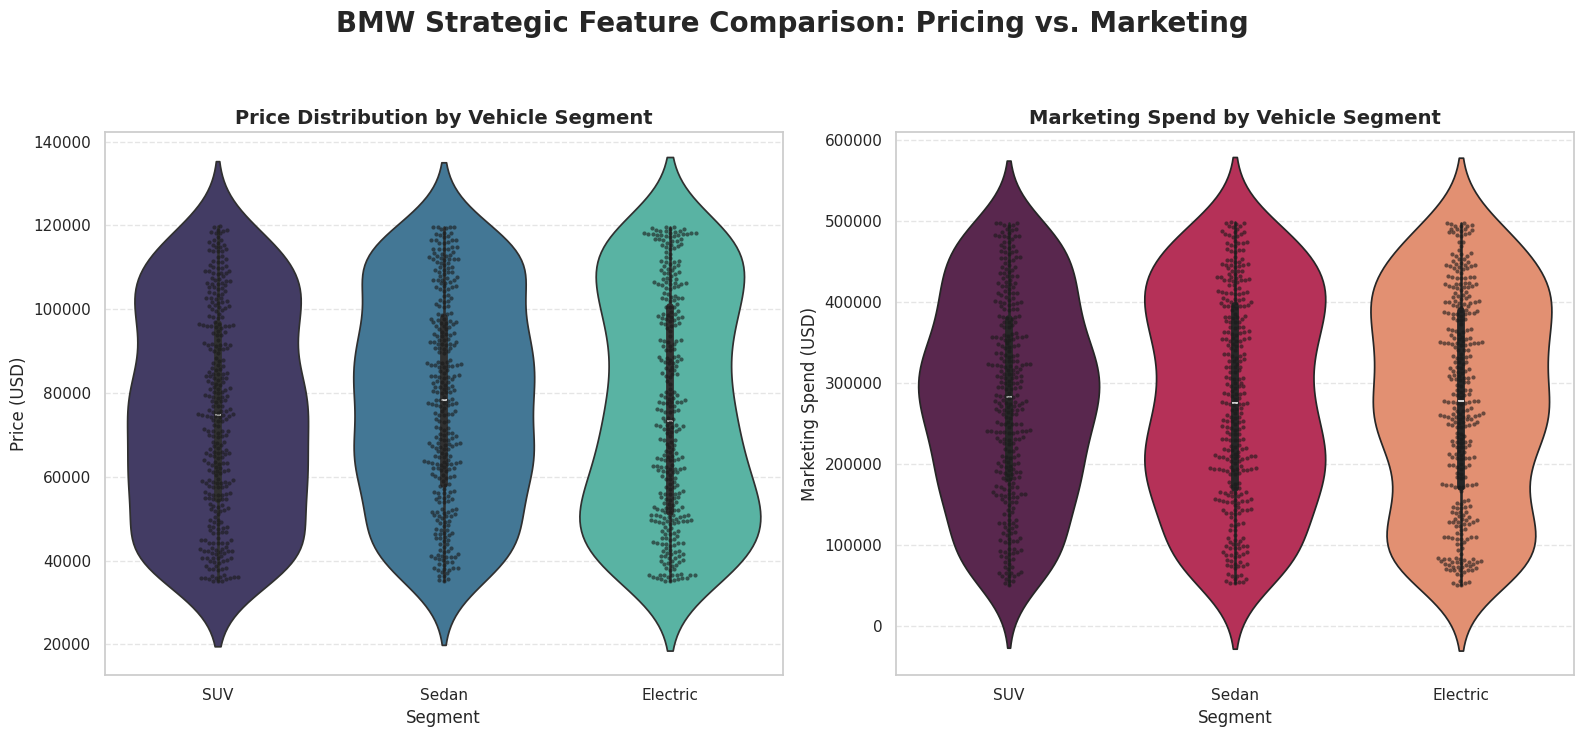

In [28]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Price Distribution
sns.violinplot(x='segment', y='price_usd', data=df, palette="mako", ax=ax[0])
sns.swarmplot(x='segment', y='price_usd', data=df, color='k', size=3, ax=ax[0], alpha=0.6)
ax[0].set_title('Price Distribution by Vehicle Segment', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Segment', fontsize=12)
ax[0].set_ylabel('Price (USD)', fontsize=12)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

# Marketing Spend Distribution
sns.violinplot(x='segment', y='marketing_spend_usd', data=df, palette="rocket", ax=ax[1])
sns.swarmplot(x='segment', y='marketing_spend_usd', data=df, color='k', size=3, ax=ax[1], alpha=0.6)
ax[1].set_title('Marketing Spend by Vehicle Segment', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Segment', fontsize=12)
ax[1].set_ylabel('Marketing Spend (USD)', fontsize=12)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)

# Main Title
plt.suptitle('BMW Strategic Feature Comparison: Pricing vs. Marketing', fontsize=20, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()
sns.reset_orig()

## Thank you..pls upvote!!!!!